## Logistic Regression
Logistic Regression is a supervised machine learning algorithm used for classification problems, where the output is categorical (usually 0 or 1).


y = 1\(1 + e^{-z))

z=m​x+b

Where:

y = predicted output

x = input variable

m = slope (coefficient)

c = intercept

### Data Preprocessing

##### 1.Importing Libraries

In [284]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

##### 2.Importing datset

In [285]:
import seaborn as sns
df = sns.load_dataset('titanic')
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


##### 3.Data Information

In [286]:
print("INFO")
df.info()
print("------------------------------------------------------------------")



INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
------------------------------------------------------------------


In [287]:
print("Statistical Summary")
df.describe()


Statistical Summary


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [288]:
print("Checking Null Values")
df.isnull().sum()

Checking Null Values


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [289]:
df['age']=df['age'].fillna(df['age'].mean())
df['fare']=df['fare'].fillna(df['fare'].mean())

In [290]:
print("Columns")
df.columns

Columns


Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

#### Exploratory Data Analysis
Exploratory Data Analysis (EDA) is the process of analyzing and understanding a dataset using statistics and visualizations to discover patterns, trends, relationships, and anomalies before building a machine learning model.

##### 1.Checking correlations

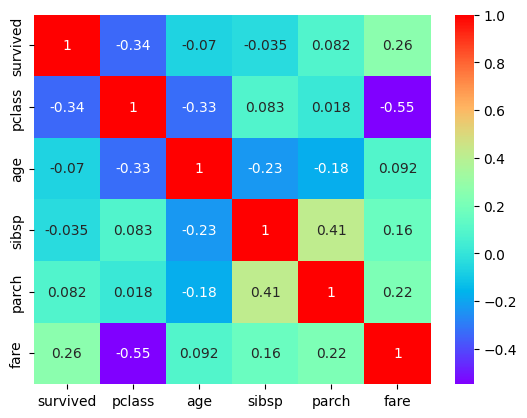

In [291]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='rainbow')
plt.show()

##### 2. Univariate Analysis

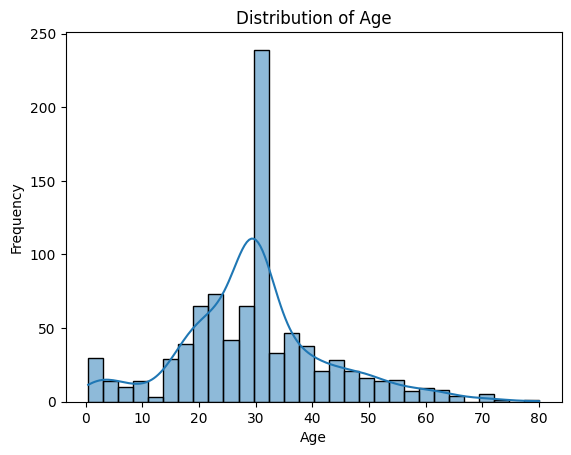

In [292]:
sns.histplot(df['age'], kde=True)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Age")
plt.show()

##### 2. Bivariate Analysis

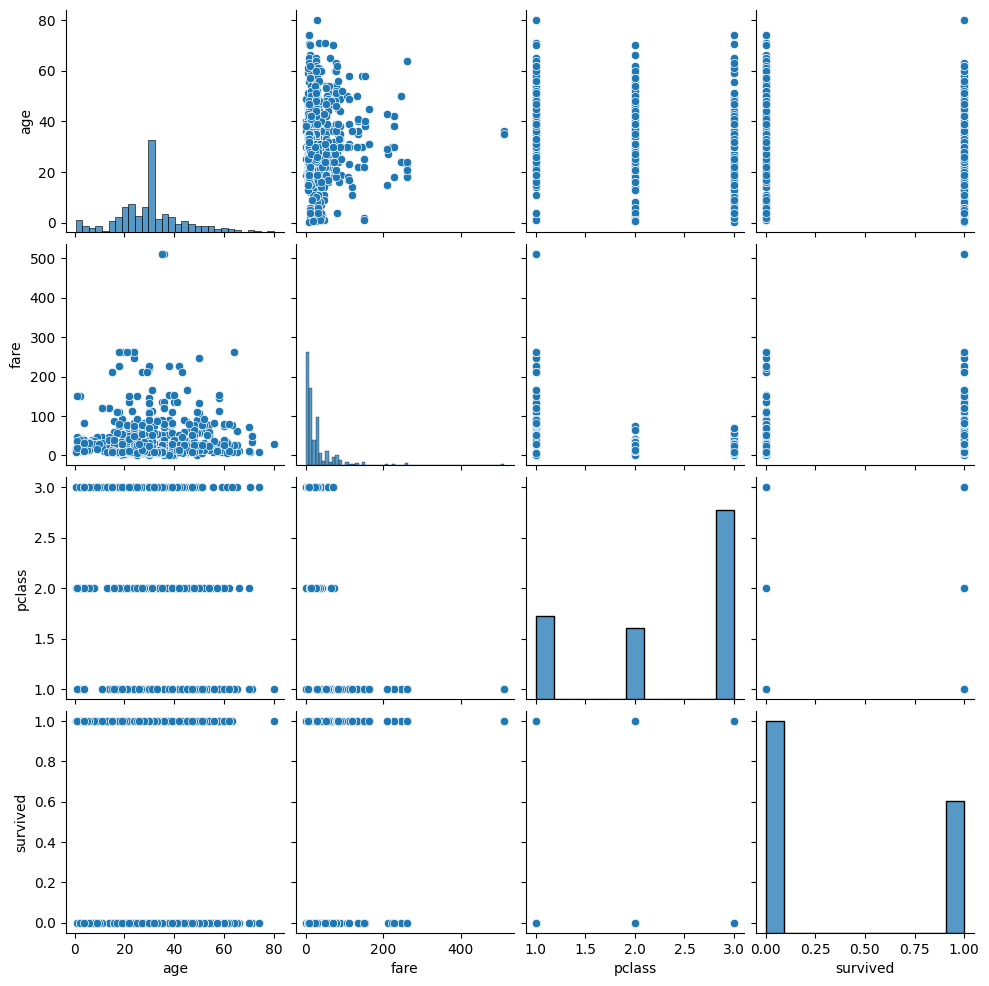

In [293]:
sns.pairplot(df[["age", "fare", "pclass", "survived"]])
plt.show()

##### 3.Feature Engeenering

###### 1.Convert Catigorical features values into 1 and 0

In [294]:
df['sex'] = df['sex'].map({'male':0, 'female':1})

In [295]:
df['sex'] = df['sex'].map({'male': 1, 'female': 0})     
df = pd.get_dummies(df, columns=["embarked"], drop_first=False)
df['embarked_Q'] = df['embarked_Q'].astype(int)
df['embarked_C'] = df['embarked_C'].astype(int)
df['embarked_S'] = df['embarked_S'].astype(int)

###### 2.Creating 3d scatter plot

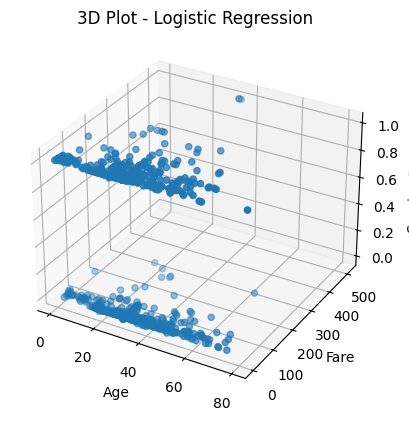

In [296]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df["age"], df["fare"], df["survived"])

ax.set_xlabel("Age")
ax.set_ylabel("Fare")
ax.set_zlabel("Survived (0/1)")

plt.title("3D Plot - Logistic Regression")
plt.show()

###### 3.Drop Unncessary columns

In [297]:
print(df.columns)

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'class',
       'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone',
       'embarked_C', 'embarked_Q', 'embarked_S'],
      dtype='object')


In [298]:
# Drop leakage + string columns
df.drop(['alive', 'class', 'who', 'deck', 'embark_town'], axis=1, inplace=True)

##### 4.Logistic Regression

###### 1.Train test split

In [299]:
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop('survived', axis=1)
y = df['survived']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

###### 2.Applying Standard Scaler

In [300]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [301]:
num_cols = ["age", "fare"]

X_train.loc[:, num_cols] = scaler.fit_transform(X_train[num_cols])
X_test.loc[:, num_cols] = scaler.transform(X_test[num_cols])

###### 3.Model training

In [304]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model = LogisticRegression(max_iter=1000)
X_train = X_train.drop(['sex'], axis=1)
X_test = X_test.drop(['sex'], axis=1)
model.fit(X_train, y_train)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [305]:
y_pred = model.predict(X_test)

###### 4.Actual vs Predicted

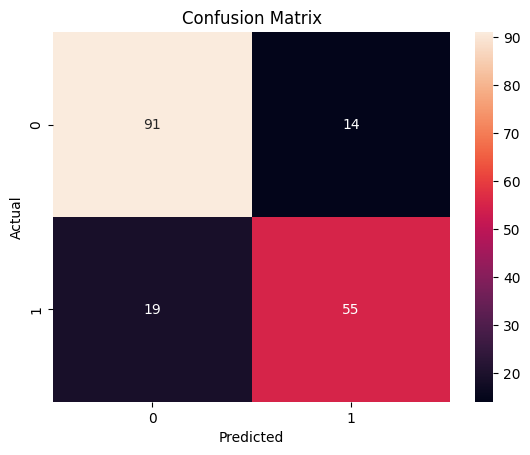

In [306]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

###### Actual vs Predicted Scatter Plot

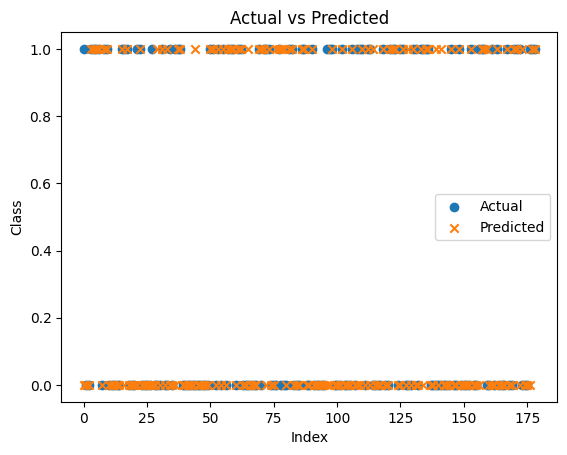

In [307]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(range(len(y_test)), y_test, label="Actual")
plt.scatter(range(len(y_pred)), y_pred, marker='x', label="Predicted")
plt.legend()
plt.title("Actual vs Predicted")
plt.xlabel("Index")
plt.ylabel("Class")
plt.show()

###### 5.Probability Plot

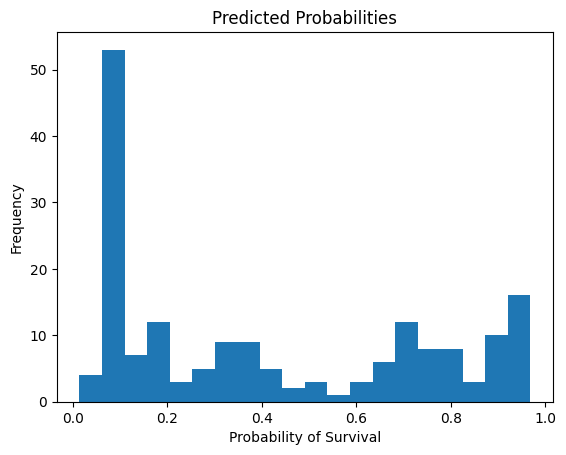

In [308]:
y_prob = model.predict_proba(X_test)[:, 1]

plt.figure()
plt.hist(y_prob, bins=20)
plt.title("Predicted Probabilities")
plt.xlabel("Probability of Survival")
plt.ylabel("Frequency")
plt.show()

##### 5.Model Evaluation

In [309]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8156424581005587

Confusion Matrix:
 [[91 14]
 [19 55]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.81      0.82      0.81       179

